In [1]:
import os
os.chdir('..')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.objectives import Objective

In [4]:
# Loads checkpoint to visualise
CHECKPOINT_PATH = 'saved_models/maddist-medium-antmaze.pt'
checkpoint = Objective.load_checkpoint(CHECKPOINT_PATH)

In [5]:
# Gets observations and their corresponding (centred) positions
obs = checkpoint.dataset.observations

original_pos = checkpoint.dataset.infos['pos'].copy()
centre = (original_pos.max(axis=0) + original_pos.min(axis=0)) / 2.0
pos = original_pos - centre

In [6]:
# Gets reference 'goal' observation which is closest to some target coordinate
target_coord = np.array([-1.5, 6.25])
ref_idx = np.linalg.norm(pos - target_coord, axis=1).argmin()
ref_obs = obs[ref_idx]
ref_pos = pos[ref_idx]

print(f"Reference Point Selected at Index {ref_idx} - True Position: ({ref_pos[0]:.2f}, {ref_pos[1]:.2f})")
obs_tensor = torch.from_numpy(obs)
ref_tensor = torch.from_numpy(obs[ref_idx]).unsqueeze(0)

print("Calculating distances...")
distances = checkpoint.distance(obs_tensor, ref_tensor, batch_size=512).numpy()

Reference Point Selected at Index 182341 - True Position: (-1.50, 6.25)
Calculating distances...


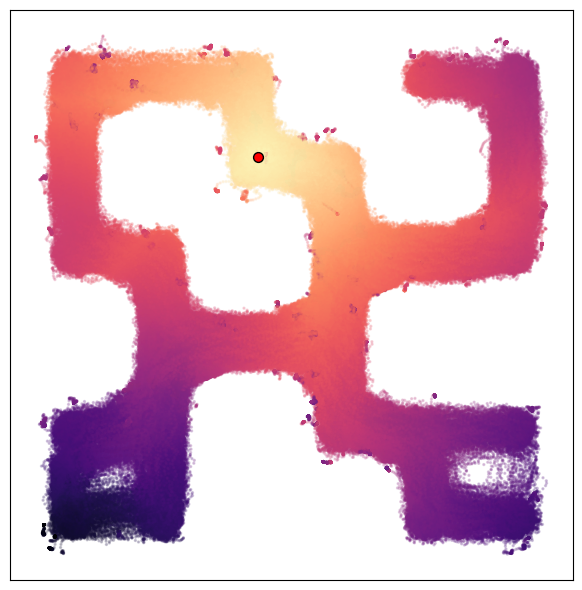

In [7]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_aspect('equal', adjustable='box')

# Scatter of observations, coloured by distances
scatter = ax.scatter(pos[:, 0], pos[:, 1], c=distances, cmap='magma_r', s=2, alpha=0.2)

# Plots the reference goal point
ax.scatter(ref_pos[0], ref_pos[1], c='red', edgecolors='black', linewidths=1, s=50, label='Goal', zorder=5)

ax.set_xticks([])
ax.set_yticks([])

fig.tight_layout()
plt.show()